In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pandas.core.config_init import styler_decimal
from sklearn.model_selection import train_test_split

sns.set_theme(style="darkgrid")
pd.set_option('display.float_format', '{:.2f}'.format)

fp = 'data/train.json'
target_col = 'price'
df = pd.read_json(fp)

In [153]:
lower_price = df[target_col].quantile(0.01)
upper_price = df[target_col].quantile(0.99)
df_clean = df[(df[target_col] > lower_price)
              &
              (df[target_col] < upper_price)].copy()

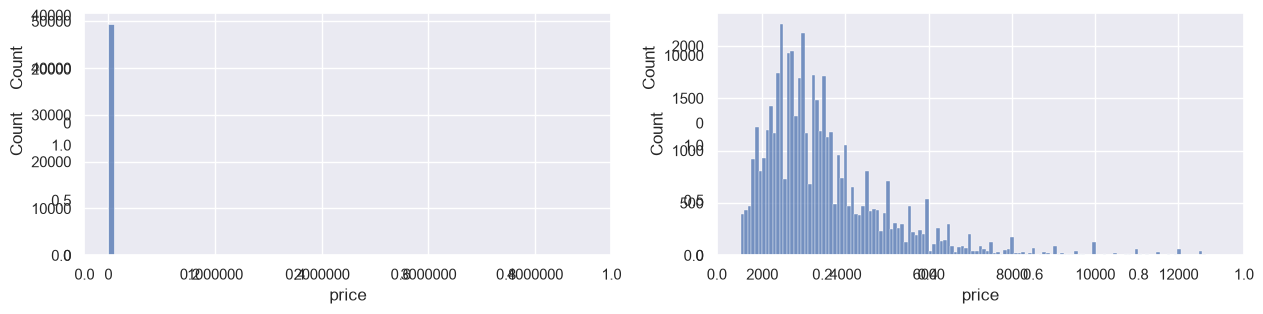

In [154]:
fig, axes = plt.subplots(2, 2, figsize=(38, 8, 'cm'))

plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=88)
plt.ticklabel_format(style='plain', axis='both')

plt.subplot(1, 2, 2)
sns.histplot(df_clean['price'])

plt.subplot(2, 2, 1)
sns.histplot(df_clean['bathrooms'])

plt.subplot(2, 2, 2)
sns.histplot(df_clean['bedrooms'])

plt.show()

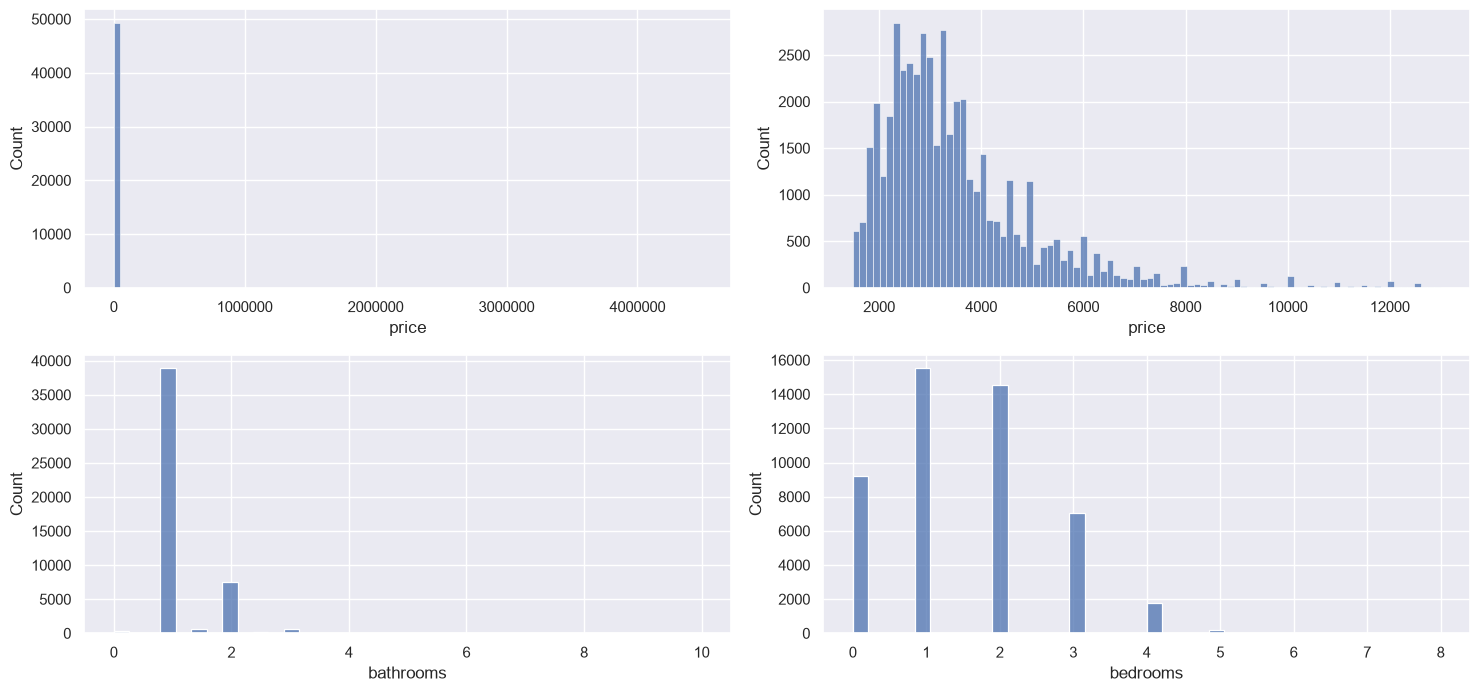

In [155]:
fig, axes = plt.subplots(2, 2, figsize=(38, 18, 'cm'))

sns.histplot(df['price'], bins=88, ax=axes[0, 0]).ticklabel_format(style='plain')

sns.histplot(df_clean['price'], bins=88, ax=axes[0, 1])

sns.histplot(df_clean['bathrooms'], ax=axes[1, 0], bins=38)

sns.histplot(df_clean['bedrooms'], ax=axes[1, 1], bins=38)

plt.tight_layout()
plt.show()

In [156]:
train_df, test_df = train_test_split(df_clean, test_size=0.25, random_state=42)
train_df.to_csv('train_data.csv', index=False)
test_df.to_csv('test_data.csv', index=False)

In [157]:
def clean_feature_name(value):
    """Убираем скобки, кавычки и пробелы; все символы -> строчные."""
    return (str(value)
            # .replace("[", "")
            # .replace("]", "")
            # .replace("'", "")
            # .replace('"', "")
            # .lower()  # все символы в нижний регистр
            # .replace(" ", "")
            )


# train_df["features"] = df_clean["features"].apply(
#     lambda feats: [str(f).lower() for f in feats] if isinstance(feats, list) else feats
#     )

# Сразу строим Counter через update() — без промежуточных списков
feature_counter_raw = Counter()
feature_counter_clean = Counter()

for feats in train_df["features"]:
    if isinstance(feats, list) and len(feats) == 0:
        feature_counter_raw.update([''])
        feature_counter_clean.update([''])
    else:
        raw_vals = [str(f) for f in feats]
        feature_counter_raw.update(raw_vals)
        feature_counter_clean.update(clean_feature_name(v) for v in raw_vals)

print("Популярные признаки")
for name, count in feature_counter_raw.most_common(21):
    print(f"  ('{name}', {count})")

# Итоговые топ-20 (с удалением пробелов) ---
unique_features_count = len(feature_counter_raw)
# unique_features_count = len(feature_counter_clean)


top_21_clean = feature_counter_clean.most_common(21)
top_20_features = [name for name, _ in top_21_clean if name]

print(f"\nКоличество уникальных значений после очистки: {unique_features_count}")
print("Топ-20 признаков:")
print(top_20_features)

Популярные признаки
  ('Elevator', 19046)
  ('Hardwood Floors', 17402)
  ('Cats Allowed', 17317)
  ('Dogs Allowed', 16209)
  ('Doorman', 15415)
  ('Dishwasher', 15030)
  ('No Fee', 13325)
  ('Laundry in Building', 12060)
  ('Fitness Center', 9737)
  ('Pre-War', 6737)
  ('Laundry in Unit', 6328)
  ('Roof Deck', 4811)
  ('Outdoor Space', 3891)
  ('Dining Room', 3680)
  ('High Speed Internet', 3191)
  ('', 2345)
  ('Balcony', 2175)
  ('Swimming Pool', 1973)
  ('Laundry In Building', 1957)
  ('New Construction', 1874)
  ('Terrace', 1647)

Количество уникальных значений после очистки: 1264
Топ-20 признаков:
['Elevator', 'Hardwood Floors', 'Cats Allowed', 'Dogs Allowed', 'Doorman', 'Dishwasher', 'No Fee', 'Laundry in Building', 'Fitness Center', 'Pre-War', 'Laundry in Unit', 'Roof Deck', 'Outdoor Space', 'Dining Room', 'High Speed Internet', 'Balcony', 'Swimming Pool', 'Laundry In Building', 'New Construction', 'Terrace']
